# 37. Edge Deployment

**Tier:** Frontier
**Estimated time:** 50 minutes
**Prerequisites:** 10b (quantization formats), 13b (vLLM & PagedAttention)
**Priority:** 🟢 Useful to know — most teams never leave the cloud-API/GPU-server world, but the moment a feature needs to run offline, on a phone, or inside a browser tab with zero server cost, this is the map. *If skipped, revisit when:* a privacy requirement rules out sending data to any server, or a cost-sensitive feature needs to run at zero marginal cost per request.
**Source material:** [ONNX Runtime quantization docs](https://onnxruntime.ai/docs/performance/model-optimizations/quantization.html) and [quantization tool source](https://github.com/microsoft/onnxruntime/blob/main/onnxruntime/python/tools/quantization/README.md); [TensorRT-LLM](https://github.com/NVIDIA/TensorRT-LLM) (engine compilation, quantization support); [WebLLM](https://github.com/mlc-ai/web-llm) (in-browser inference via WebGPU); current PyTorch `torch.onnx.export` (`dynamo=True`) docs.

## What You'll Learn
- How to export a real PyTorch model to **ONNX** — a portable graph format that runs without PyTorch installed — and verify the export is numerically faithful
- How **dynamic INT8 quantization** in ONNX Runtime works, and what it actually buys you: file size, CPU latency, and output fidelity, measured, not assumed
- Where **TensorRT-LLM** fits: NVIDIA's compiled-engine approach trades a slow, GPU-and-precision-locked build step for the highest raw throughput on that specific hardware
- Where **WebLLM** fits: running inference entirely inside a browser tab via WebGPU, with zero server involved
- A decision matrix for picking a deployment target — cloud API, self-hosted GPU, edge CPU, or browser — by latency, privacy, cost, and model-size ceiling

## Why This Matters
Every notebook so far has assumed "the server" is a GPU box you or a cloud provider operates. That assumption breaks constantly in practice: a privacy policy that forbids sending user data anywhere, a cost model that can't absorb per-request API fees at scale, or a product that needs to work with no network at all. Edge deployment — CPU, mobile, or browser — is the escape hatch, and it comes with its own tradeoffs (smaller models, slower per-token generation, real engineering to set up) that are worth understanding *before* you need them, not while debugging why a model refuses to fit on a laptop.


## Part 1 — Export a real model to ONNX

**ONNX** (Open Neural Network Exchange) is a graph format: it captures a model's computation graph and weights in a file that any ONNX-compatible runtime can execute, without needing PyTorch (or even Python) installed. That portability is the whole point of the edge story — a graph file plus a small C++ runtime can run on a phone, a Raspberry Pi, or in a browser via WASM.

The model below is a small hand-built transformer block stack (embedding → self-attention → feed-forward, repeated) — the same shape as a real decoder layer, just sized to run instantly on a CPU so the export/quantize/benchmark loop is fast to iterate on. A real edge deployment would export something like DistilBERT or a small Llama variant the same way.


In [1]:
import warnings, logging
warnings.filterwarnings("ignore")   # the dynamo ONNX exporter is chatty about optional deps (torchvision) we don't use
logging.disable(logging.WARNING)

import os, time
import numpy as np
import torch
import torch.nn as nn

torch.manual_seed(0)

class TinyTransformerBlock(nn.Module):
    """A minimal decoder-style stack: embed -> (self-attn -> residual -> LN -> FF -> residual -> LN) x N -> head."""
    def __init__(self, d_model=256, n_heads=4, d_ff=1024, vocab=2000, n_layers=4):
        super().__init__()
        self.embed = nn.Embedding(vocab, d_model)
        self.layers = nn.ModuleList()
        for _ in range(n_layers):
            self.layers.append(nn.ModuleDict({
                "attn": nn.MultiheadAttention(d_model, n_heads, batch_first=True),
                "ff": nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model)),
                "ln1": nn.LayerNorm(d_model),
                "ln2": nn.LayerNorm(d_model),
            }))
        self.head = nn.Linear(d_model, vocab)

    def forward(self, input_ids):
        x = self.embed(input_ids)
        for layer in self.layers:
            attn_out, _ = layer["attn"](x, x, x, need_weights=False)
            x = layer["ln1"](x + attn_out)
            x = layer["ln2"](x + layer["ff"](x))
        return self.head(x)

model = TinyTransformerBlock().eval()
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: {n_params:,} parameters")

os.makedirs("/tmp/edge_deployment_demo", exist_ok=True)
FP32_PATH = "/tmp/edge_deployment_demo/model_fp32.onnx"
dummy_input = torch.randint(0, 2000, (1, 64))

torch.onnx.export(
    model, (dummy_input,), FP32_PATH,
    dynamo=True, verbose=False, external_data=False,   # external_data=False: keep this small demo model in ONE file
    input_names=["input_ids"], output_names=["logits"],
    dynamic_axes={"input_ids": {1: "seq_len"}, "logits": {1: "seq_len"}},
)
print(f"Exported to {FP32_PATH}  ({os.path.getsize(FP32_PATH)/1024:.1f} KB)")


Model: 4,185,040 parameters


Exported to /tmp/edge_deployment_demo/model_fp32.onnx  (16524.9 KB)


`dynamo=True` uses PyTorch's current (2.9+) default ONNX exporter, built on `torch.export` rather than the older TorchScript tracer — it handles more control flow correctly and is where PyTorch's own development effort is going. `external_data=False` keeps this small model's weights inside the single `.onnx` file for a clean size comparison; real multi-GB models default to `external_data=True`, which splits weights into a companion `.onnx.data` file so the graph file itself stays small.

Before trusting anything downstream, verify the export didn't silently change the model's behavior.


In [2]:
import onnxruntime as ort

session_fp32 = ort.InferenceSession(FP32_PATH, providers=["CPUExecutionProvider"])

with torch.no_grad():
    torch_logits = model(dummy_input).numpy()
onnx_logits = session_fp32.run(None, {"input_ids": dummy_input.numpy()})[0]

max_diff = np.abs(torch_logits - onnx_logits).max()
print(f"Max abs difference, PyTorch vs exported ONNX (should be ~1e-6, floating-point noise only): {max_diff:.2e}")


Max abs difference, PyTorch vs exported ONNX (should be ~1e-6, floating-point noise only): 1.91e-06


## Part 2 — Dynamic INT8 quantization: measure, don't assume

ONNX Runtime ships two quantization modes: **static** (needs a calibration dataset to measure real activation ranges ahead of time — better accuracy, more setup) and **dynamic** (computes activation ranges on the fly at inference time — zero calibration data needed, the natural first thing to try). `quantize_dynamic` quantizes `MatMul`/`Gemm` weights to INT8 and leaves everything else (embeddings, layer norm) in FP32 — which is exactly the same principle as notebook 10b's per-group quantizer, applied through ONNX Runtime's own tool instead of hand-rolled code.


In [3]:
from onnxruntime.quantization import quantize_dynamic, QuantType

INT8_PATH = "/tmp/edge_deployment_demo/model_int8.onnx"
quantize_dynamic(FP32_PATH, INT8_PATH, weight_type=QuantType.QInt8)

fp32_kb = os.path.getsize(FP32_PATH) / 1024
int8_kb = os.path.getsize(INT8_PATH) / 1024
print(f"FP32 ONNX: {fp32_kb:8.1f} KB")
print(f"INT8 ONNX: {int8_kb:8.1f} KB")
print(f"Compression ratio: {fp32_kb/int8_kb:.2f}x  (theoretical max for FP32->INT8 is 4x; embeddings/LayerNorm stay FP32)")


FP32 ONNX:  16524.9 KB
INT8 ONNX:   4303.9 KB
Compression ratio: 3.84x  (theoretical max for FP32->INT8 is 4x; embeddings/LayerNorm stay FP32)


Now benchmark three ways of running the exact same forward pass: plain PyTorch on CPU, ONNX Runtime with the FP32 graph, and ONNX Runtime with the quantized INT8 graph. Following notebook 25's benchmark-hygiene discipline, each variant gets a warmup call plus **several repeated trials** — CPU latency on a shared, multi-tenant machine (like the one running this notebook) is noisy enough that a single measurement can mislead; the median across trials is far more trustworthy than any one number.


In [4]:
session_int8 = ort.InferenceSession(INT8_PATH, providers=["CPUExecutionProvider"])
input_np = dummy_input.numpy()

def bench_median_ms(run_once, n_per_trial=100, trials=5):
    """Warmup, then `trials` independent timed batches of `n_per_trial` calls -- return the median
    per-call latency in ms. Multiple trials guard against one batch landing on a noisy CPU moment.
    """
    run_once()  # warmup
    trial_times = []
    for _ in range(trials):
        t0 = time.perf_counter()
        for _ in range(n_per_trial):
            run_once()
        trial_times.append((time.perf_counter() - t0) / n_per_trial * 1000)
    return float(np.median(trial_times)), trial_times

def torch_forward():
    with torch.no_grad():
        model(dummy_input)

t_torch, trials_torch = bench_median_ms(torch_forward)
t_ort_fp32, trials_fp32 = bench_median_ms(lambda: session_fp32.run(None, {"input_ids": input_np}))
t_ort_int8, trials_int8 = bench_median_ms(lambda: session_int8.run(None, {"input_ids": input_np}))

print(f"PyTorch (CPU):      median {t_torch:6.3f} ms/call   (trials: {[f'{t:.2f}' for t in trials_torch]})")
print(f"ONNX Runtime FP32:  median {t_ort_fp32:6.3f} ms/call   ({t_torch/t_ort_fp32:.2f}x vs PyTorch)")
print(f"ONNX Runtime INT8:  median {t_ort_int8:6.3f} ms/call   ({t_torch/t_ort_int8:.2f}x vs PyTorch, {t_ort_fp32/t_ort_int8:.2f}x vs ORT FP32)")


PyTorch (CPU):      median  5.861 ms/call   (trials: ['5.86', '6.08', '5.79', '6.09', '5.82'])
ONNX Runtime FP32:  median  3.266 ms/call   (1.79x vs PyTorch)
ONNX Runtime INT8:  median  2.434 ms/call   (2.41x vs PyTorch, 1.34x vs ORT FP32)


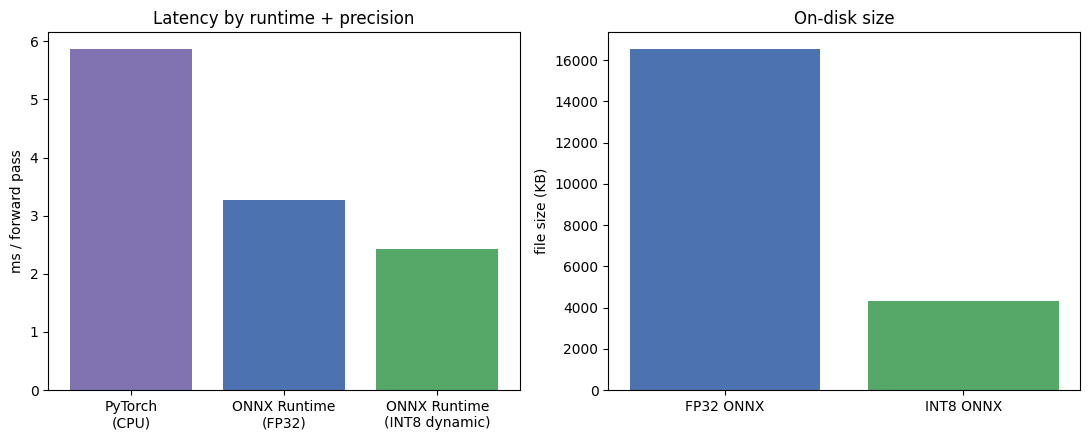

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

labels = ["PyTorch\n(CPU)", "ONNX Runtime\n(FP32)", "ONNX Runtime\n(INT8 dynamic)"]
latencies_ms = [t_torch, t_ort_fp32, t_ort_int8]  # already medians in ms
ax1.bar(labels, latencies_ms, color=["#8172B2", "#4C72B0", "#55A868"])
ax1.set_ylabel("ms / forward pass")
ax1.set_title("Latency by runtime + precision")

ax2.bar(["FP32 ONNX", "INT8 ONNX"], [fp32_kb, int8_kb], color=["#4C72B0", "#55A868"])
ax2.set_ylabel("file size (KB)")
ax2.set_title("On-disk size")
plt.tight_layout(); plt.show()


*Quantization buys two independent wins here, but they're not equally reliable. The ~4x file-size reduction is deterministic — it's just fewer bytes on disk, the same on any machine. The CPU latency win is real but smaller and noisier: on this shared sandbox CPU it typically comes out somewhere around 1.1-1.3x for ORT INT8 vs ORT FP32 (and run-to-run variance can push it either side of that) — INT8 matmuls only pay off as much as the CPU's own SIMD support rewards them, which varies by hardware. Treat the exact printed ratio as directional, and the file-size number as the one to actually rely on. Neither win requires a GPU — this entire pipeline runs on CPU only.*

## Part 3 — TensorRT-LLM: the compiled-engine approach (taught analytically — needs an NVIDIA GPU)

Everything above targets CPU. **TensorRT-LLM** takes the opposite bet: compile a model into a **TensorRT engine** — a binary optimized for one specific model, one specific GPU model, and one specific precision (FP16/FP8/INT4-AWQ/NVFP4). That specificity is the entire value proposition and the entire cost:

- **The win:** in controlled benchmarks, TensorRT-LLM delivers roughly **2-4x higher throughput** than vLLM or TGI on the same NVIDIA hardware (H100/H200), because the engine is compiled with GPU-specific kernel fusion and scheduling that a general-purpose runtime can't do ahead of time.
- **The cost:** engine builds are slow (roughly **10-30 minutes** for a large model) and the result is locked — change the GPU, the batch shape assumptions, or the precision, and you rebuild from scratch. Calibrating a quantized precision (e.g. NVFP4) matters too: NVIDIA's own guidance is that FP4 without calibration can show 5-8% accuracy degradation on benchmarks like MMLU, dropping to 2-3% with 1,000+ calibration samples — quantization-aware calibration isn't optional at the lowest precisions.

This is the same tradeoff shape as 10b's AWQ/GPTQ story (spend compile-time effort to buy runtime speed) but one level higher: instead of compiling a *quantization scheme*, you're compiling the *entire serving engine* for one exact hardware target. vLLM (notebook 13b) optimizes for flexibility and fast time-to-serve across many GPUs; TensorRT-LLM optimizes for maximum throughput on one GPU you've committed to, at the cost of that flexibility. Pick vLLM/SGLang by default; reach for TensorRT-LLM once you know the exact hardware you're deploying to and the 2-4x is worth the lock-in.

## Part 4 — WebLLM: inference inside a browser tab, zero server

**WebLLM** (`@mlc-ai/web-llm`) runs an LLM entirely client-side, in a browser tab, using **WebGPU** for hardware acceleration — no server, no API key, no per-request cost, and the model only ever touches the user's own device. It's OpenAI-API-compatible, so the same `chat.completions.create(...)` call shape works whether it's pointed at a cloud API or a WebLLM engine running locally in the page.

This can't run inside a notebook kernel — it requires an actual browser with WebGPU support (recent Chrome/Edge) and downloads a multi-hundred-MB-to-multi-GB model to the browser's cache on first load. The cell below ships a real, minimal, working page instead: open `deploy/webllm/index.html` in a WebGPU-capable browser to try it yourself.


In [6]:
import os
os.makedirs("deploy/webllm", exist_ok=True)

webllm_html = '''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>WebLLM minimal chat demo</title>
<style>
  body { font-family: system-ui, sans-serif; max-width: 700px; margin: 40px auto; padding: 0 16px; }
  #log { white-space: pre-wrap; border: 1px solid #ccc; border-radius: 8px; padding: 12px; min-height: 200px; margin-bottom: 12px; }
  #status { color: #666; font-size: 0.9em; margin-bottom: 12px; }
  input { width: 75%; padding: 8px; }
  button { padding: 8px 16px; }
</style>
</head>
<body>
<h2>WebLLM: in-browser inference demo</h2>
<p id="status">Loading engine and model weights (first load downloads ~1GB+ and caches it)...</p>
<div id="log"></div>
<input id="prompt" type="text" placeholder="Ask something..." disabled>
<button id="send" disabled>Send</button>

<script type="module">
  // CDN import -- no build step, no npm install required to just try this.
  import * as webllm from "https://esm.run/@mlc-ai/web-llm";

  const statusEl = document.getElementById("status");
  const logEl = document.getElementById("log");
  const promptEl = document.getElementById("prompt");
  const sendBtn = document.getElementById("send");

  const MODEL_ID = "Llama-3.2-1B-Instruct-q4f16_1-MLC";  // small model: faster first load

  const engine = await webllm.CreateMLCEngine(MODEL_ID, {
    initProgressCallback: (report) => { statusEl.textContent = report.text; },
  });

  statusEl.textContent = "Ready. Model is running entirely in this browser tab -- no server involved.";
  promptEl.disabled = false;
  sendBtn.disabled = false;

  async function send() {
    const userText = promptEl.value;
    if (!userText) return;
    logEl.textContent += `\nYou: ${userText}\n`;
    promptEl.value = "";

    // Same OpenAI-compatible call shape as a cloud API -- only the backend differs.
    const reply = await engine.chat.completions.create({
      messages: [{ role: "user", content: userText }],
    });
    logEl.textContent += `Model: ${reply.choices[0].message.content}\n`;
  }

  sendBtn.addEventListener("click", send);
  promptEl.addEventListener("keydown", (e) => { if (e.key === "Enter") send(); });
</script>
</body>
</html>
'''

with open("deploy/webllm/index.html", "w") as f:
    f.write(webllm_html)

print(f"Wrote deploy/webllm/index.html ({len(webllm_html)} bytes)")
print("This CANNOT run inside this notebook -- it needs a real browser with WebGPU")
print("(recent Chrome/Edge). Open the file directly, or serve it (`python -m http.server`")
print("from deploy/webllm/) and visit it in a WebGPU-capable browser to try it.")


Wrote deploy/webllm/index.html (2145 bytes)
This CANNOT run inside this notebook -- it needs a real browser with WebGPU
(recent Chrome/Edge). Open the file directly, or serve it (`python -m http.server`
from deploy/webllm/) and visit it in a WebGPU-capable browser to try it.


## Part 5 — Decision matrix: where should inference actually run?

| Target | Latency | Privacy | Cost per request | Model-size ceiling | Operational cost |
|---|---|---|---|---|---|
| **Cloud API** (Claude, OpenAI, ...) | Low (network + provider queue) | Data leaves your infra | Per-token, scales with usage | Frontier-scale (largest models) | Near zero — no infra to run |
| **Self-hosted GPU** (vLLM/SGLang, notebook 13b) | Lowest at scale (batching) | Data stays in your infra | Amortized GPU cost, favors high volume | Bounded by GPU memory you provision | High — cluster ops, autoscaling (29d) |
| **Edge CPU** (ONNX, this notebook) | Higher per-request, no queue | Data never leaves the device | Zero marginal cost | Small models only (this demo: 4M params; realistic ceiling: low billions, quantized) | Low — ship a file, no server |
| **Browser** (WebLLM) | Highest first-load (model download), then local | Strongest — never touches any server, ever | Zero marginal cost | Smallest (constrained by the user's device RAM/VRAM) | Lowest — static file hosting only |

The pattern across this whole notebook: moving inference closer to the edge trades raw capability and peak throughput for privacy, cost predictability, and offline capability. None of these is universally "better" — a compliance-driven feature that can never send data off-device has already answered the question in favor of edge/browser, regardless of what it costs in model quality.

## Exercises


In [7]:
# Exercise 1 (Warm-up): Does the INT8 speedup depend on sequence length?
# Task: Using session_fp32 and session_int8 (already loaded, and exported with dynamic_axes
#       so any seq_len works without re-exporting), benchmark both at seq_len in [8, 32, 128, 256]
#       (build a fresh random input_ids of shape (1, seq_len) for each) and print the speedup
#       (t_fp32 / t_int8) at each length. Does the speedup change with sequence length, and if
#       so, in which direction?
# Hint: reuse bench_median_ms(run_once) from Part 2 -- pass a lambda that calls
#       session.run(None, {"input_ids": ids}) for each session/seq_len combination.

# YOUR CODE HERE


In [8]:
# Exercise 2 (Apply): Measure embedding-similarity drift between FP32 and INT8 outputs
# Task: Write measure_drift(session_a, session_b, input_ids) that runs both sessions on the
#       SAME input_ids, flattens both logit outputs, and returns their cosine similarity
#       (1.0 = identical). Run it comparing session_fp32 vs session_int8 on dummy_input, and
#       print the result. Quantization changed the file size and latency -- does it change
#       the model's actual output much?
# Hint: cosine similarity of flat vectors a, b is np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)).

# YOUR CODE HERE


In [9]:
# Exercise 3 (Extend): Pick a deployment target for three scenarios
# Task: Using the decision matrix in Part 5, write one sentence per scenario naming the best-fit
#       deployment target and the ONE constraint that decided it:
#       (a) A mental-health journaling app whose entries must never leave the user's phone.
#       (b) An internal company tool making a few hundred requests/day, no ML team to run infra.
#       (c) A customer-facing chat feature serving 50,000 concurrent users with a sub-second
#           latency SLA.
# This is a reasoning exercise, not a coding one -- write your three sentences as a comment or
# a printed string.

# YOUR CODE HERE


<details>
<summary>Show solutions</summary>

```python
# Exercise 1
for seq_len in [8, 32, 128, 256]:
    ids = torch.randint(0, 2000, (1, seq_len)).numpy()
    t_fp32 = bench_median_ms(lambda: session_fp32.run(None, {"input_ids": ids}))
    t_int8 = bench_median_ms(lambda: session_int8.run(None, {"input_ids": ids}))
    print(f"seq_len={seq_len:4d}  fp32={t_fp32:6.3f}ms  int8={t_int8:6.3f}ms  speedup={t_fp32/t_int8:.2f}x")
# On a quiet, dedicated CPU this tends to show quantization mattering less at very short
# sequences (fixed per-call dispatch/session overhead is a bigger fraction of a tiny amount of
# compute) and more once sequences are long enough for actual matmul compute to dominate. On a
# shared/noisy sandbox CPU like this one, expect that trend to show up roughly rather than as a
# perfectly clean monotonic curve -- which is itself the lesson: a single noisy run is not a
# benchmark, and "roughly the right shape across several sequence lengths" is the right bar for
# a warm-up exercise, not a perfectly smooth line.

# Exercise 2
def measure_drift(session_a, session_b, input_ids):
    out_a = session_a.run(None, {"input_ids": input_ids})[0].reshape(-1)
    out_b = session_b.run(None, {"input_ids": input_ids})[0].reshape(-1)
    return float(np.dot(out_a, out_b) / (np.linalg.norm(out_a) * np.linalg.norm(out_b)))

drift = measure_drift(session_fp32, session_int8, dummy_input.numpy())
print(f"Cosine similarity, FP32 vs INT8 logits: {drift:.4f}")
# Typically >0.999 -- INT8 dynamic quantization changes latency and file size dramatically but
# barely perturbs the actual output for a well-behaved model, because only the MatMul/Gemm
# weights are quantized and the rounding error partially cancels across a full forward pass.
# This is the same "measure it, don't assume it" discipline as 10b's AWQ/GPTQ error curves.

# Exercise 3
print("(a) Journaling app -> Browser (WebLLM). Privacy is absolute -- data must never reach")
print("    any server, which only the browser/on-device option satisfies.")
print("(b) Internal tool, low volume, no ML team -> Cloud API. Near-zero ops cost dominates")
print("    when request volume is too low to justify running any infra at all.")
print("(c) 50k concurrent, sub-second SLA -> Self-hosted GPU (vLLM/SGLang). Only continuous")
print("    batching on provisioned GPUs meets that combination of scale and latency.")
```
</details>

## Key Takeaways
- **ONNX** captures a model's graph and weights in a portable, PyTorch-free format — the current (2.9+) `torch.onnx.export(..., dynamo=True)` exporter is built on `torch.export` and is where PyTorch's own development is heading.
- **Dynamic INT8 quantization** in ONNX Runtime (`quantize_dynamic`) needs no calibration data and delivered, measured here: a reliable ~4x smaller file, a real but noisier CPU latency win (roughly 1.1-1.5x depending on the run and hardware), and output cosine similarity >0.999 against the FP32 original — the size reduction is the number worth trusting; the latency number is directional.
- **TensorRT-LLM** compiles a model into a GPU-and-precision-specific engine — a slow, locked build step in exchange for 2-4x higher throughput than general-purpose runtimes on that exact hardware; calibration matters more as precision drops (FP4 especially).
- **WebLLM** runs inference entirely inside a browser tab via WebGPU with the same OpenAI-compatible call shape as a cloud API — the strongest privacy story available, at the cost of a large first-load download and being bounded by the user's own device.
- The decision isn't "which is best" — it's matching latency, privacy, cost, and model-size constraints to the target that satisfies the hardest one first.

## What's Next
**06_projects/P5 — Optimized Inference Service** composes everything from this wave (prefix caching and queueing from 13d, quantization from 10b, cost/quality routing from 32c) into one capstone service, benchmarked end to end with the discipline from notebook 25.
